In [3]:
from entsoe import EntsoePandasClient
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv('/Users/mh/Documents/energy-price-forecast/.env')

client = EntsoePandasClient(api_key=os.getenv('ENTSOE_API_KEY'))

start = pd.Timestamp('2025-01-01', tz='Europe/Berlin')
end = pd.Timestamp('2025-12-31', tz='Europe/Berlin')

ts = client.query_day_ahead_prices('DE_LU', start=start, end=end)
print(ts.head(20))

2025-01-01 00:00:00+01:00    2.16
2025-01-01 01:00:00+01:00    1.60
2025-01-01 02:00:00+01:00    0.00
2025-01-01 03:00:00+01:00   -0.01
2025-01-01 04:00:00+01:00   -0.01
2025-01-01 05:00:00+01:00   -0.06
2025-01-01 06:00:00+01:00   -0.09
2025-01-01 07:00:00+01:00   -0.01
2025-01-01 08:00:00+01:00   -0.01
2025-01-01 09:00:00+01:00   -0.04
2025-01-01 10:00:00+01:00   -0.03
2025-01-01 11:00:00+01:00   -0.10
2025-01-01 12:00:00+01:00   -0.05
2025-01-01 13:00:00+01:00   -0.10
2025-01-01 14:00:00+01:00   -1.01
2025-01-01 15:00:00+01:00   -0.01
2025-01-01 16:00:00+01:00   -0.01
2025-01-01 17:00:00+01:00    0.07
2025-01-01 18:00:00+01:00    1.01
2025-01-01 19:00:00+01:00    1.48
dtype: float64


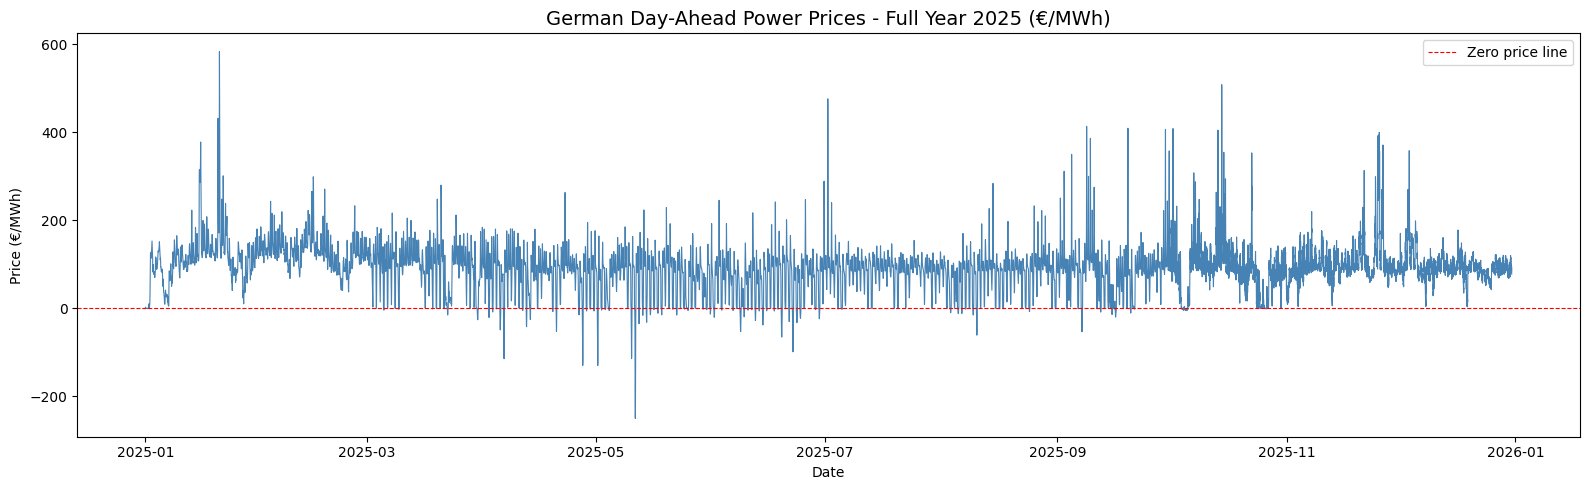

count    15291.000000
mean        90.994870
std         50.000273
min       -250.320000
25%         73.300000
50%         90.900000
75%        111.190000
max        583.400000
dtype: float64


In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 5))
plt.plot(ts.index, ts.values, linewidth=0.8, color='steelblue')
plt.title('German Day-Ahead Power Prices - Full Year 2025 (€/MWh)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (€/MWh)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.8, label='Zero price line')
plt.legend()
plt.tight_layout()
plt.show()

# Basic statistics
print(ts.describe())

In [5]:
# --- Generation: Wind & Solar ---
generation = client.query_generation('DE_LU', start=start, end=end, psr_type=None)

# Keep only Wind Onshore, Wind Offshore, Solar
gen_cols = [col for col in generation.columns 
            if any(x in str(col) for x in ['Wind Onshore', 'Wind Offshore', 'Solar'])]
generation = generation[gen_cols]

# Flatten multi-level columns if present
generation.columns = ['_'.join(col).strip() if isinstance(col, tuple) 
                      else col for col in generation.columns]

print("Generation columns:", generation.columns.tolist())
print(generation.head())

Generation columns: ['Solar_Actual Aggregated', 'Solar_Actual Consumption', 'Wind Offshore_Actual Aggregated', 'Wind Onshore_Actual Aggregated', 'Wind Onshore_Actual Consumption']
                           Solar_Actual Aggregated  Solar_Actual Consumption  \
2025-01-01 00:00:00+01:00                     9.97                       0.0   
2025-01-01 00:15:00+01:00                     9.32                       0.0   
2025-01-01 00:30:00+01:00                     9.37                       0.0   
2025-01-01 00:45:00+01:00                     9.56                       0.0   
2025-01-01 01:00:00+01:00                     9.93                       0.0   

                           Wind Offshore_Actual Aggregated  \
2025-01-01 00:00:00+01:00                          2415.09   
2025-01-01 00:15:00+01:00                          2601.31   
2025-01-01 00:30:00+01:00                          2542.27   
2025-01-01 00:45:00+01:00                          2450.01   
2025-01-01 01:00:00+01:00    

In [6]:
# --- Load ---
load = client.query_load('DE_LU', start=start, end=end)
load.name = 'load_MW'

print(load.head())

                           Actual Load
2025-01-01 00:00:00+01:00     48899.61
2025-01-01 00:15:00+01:00     48018.91
2025-01-01 00:30:00+01:00     48048.26
2025-01-01 00:45:00+01:00     47918.90
2025-01-01 01:00:00+01:00     47667.03


In [7]:
# --- Merge everything into one DataFrame ---
df = pd.DataFrame({'price_EUR_MWh': ts})
df['load_MW'] = load.resample('h').mean()
df['solar_MW'] = generation.filter(like='Solar').resample('h').mean().sum(axis=1)
df['wind_onshore_MW'] = generation.filter(like='Wind Onshore').resample('h').mean().sum(axis=1)
df['wind_offshore_MW'] = generation.filter(like='Wind Offshore').resample('h').mean().sum(axis=1)

df.dropna(inplace=True)
print(df.shape)
print(df.head())

(8736, 5)
                           price_EUR_MWh     load_MW  solar_MW  \
2025-01-01 00:00:00+01:00           2.16  48221.4200    9.5550   
2025-01-01 01:00:00+01:00           1.60  47328.2275    9.5450   
2025-01-01 02:00:00+01:00           0.00  46243.6575    9.2925   
2025-01-01 03:00:00+01:00          -0.01  45051.7875    9.4125   
2025-01-01 04:00:00+01:00          -0.01  44047.7075    9.2175   

                           wind_onshore_MW  wind_offshore_MW  
2025-01-01 00:00:00+01:00       32883.5850         2502.1700  
2025-01-01 01:00:00+01:00       33528.8575         2395.2675  
2025-01-01 02:00:00+01:00       33791.3450         2614.1375  
2025-01-01 03:00:00+01:00       32901.5425         1684.2200  
2025-01-01 04:00:00+01:00       33148.3950         1327.7375  


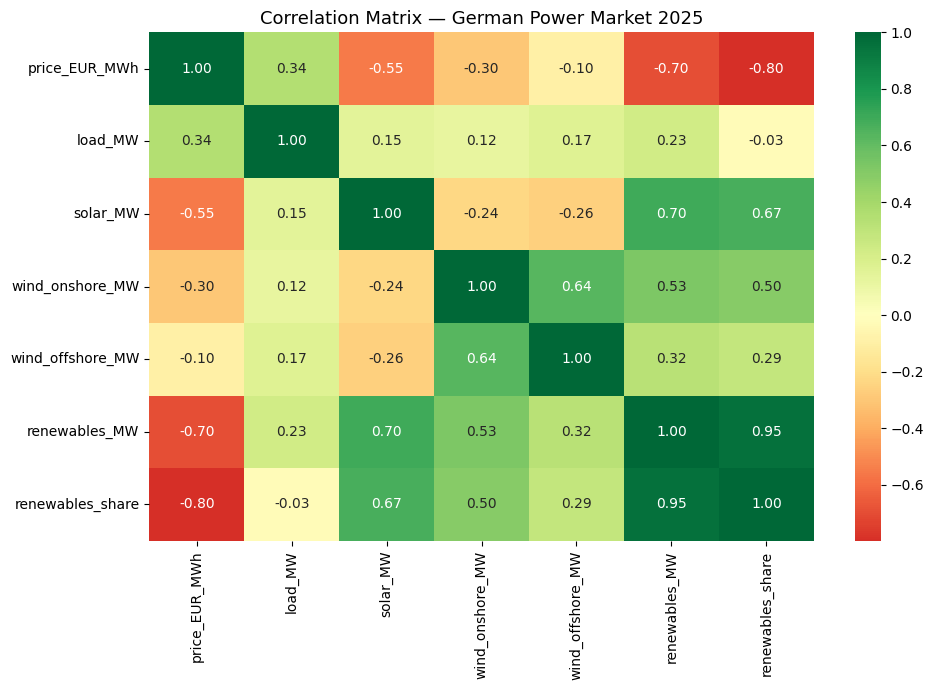

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- Derived feature: total renewables ---
df['renewables_MW'] = df['solar_MW'] + df['wind_onshore_MW'] + df['wind_offshore_MW']
df['renewables_share'] = df['renewables_MW'] / df['load_MW']

# --- Correlation matrix ---
corr = df[['price_EUR_MWh', 'load_MW', 'solar_MW', 
           'wind_onshore_MW', 'wind_offshore_MW', 
           'renewables_MW', 'renewables_share']].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Correlation Matrix — German Power Market 2025', fontsize=13)
plt.tight_layout()
plt.show()

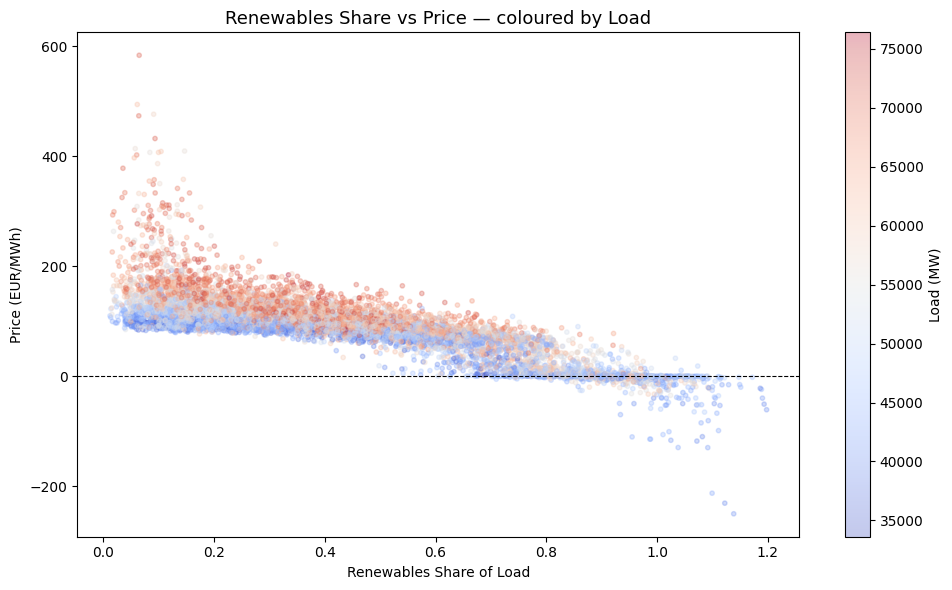

In [9]:
# --- Renewables share vs price scatter ---
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df['renewables_share'], df['price_EUR_MWh'], 
                alpha=0.3, s=10, c=df['load_MW'], cmap='coolwarm')
plt.colorbar(sc, label='Load (MW)')
ax.set_xlabel('Renewables Share of Load')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Renewables Share vs Price — coloured by Load', fontsize=13)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

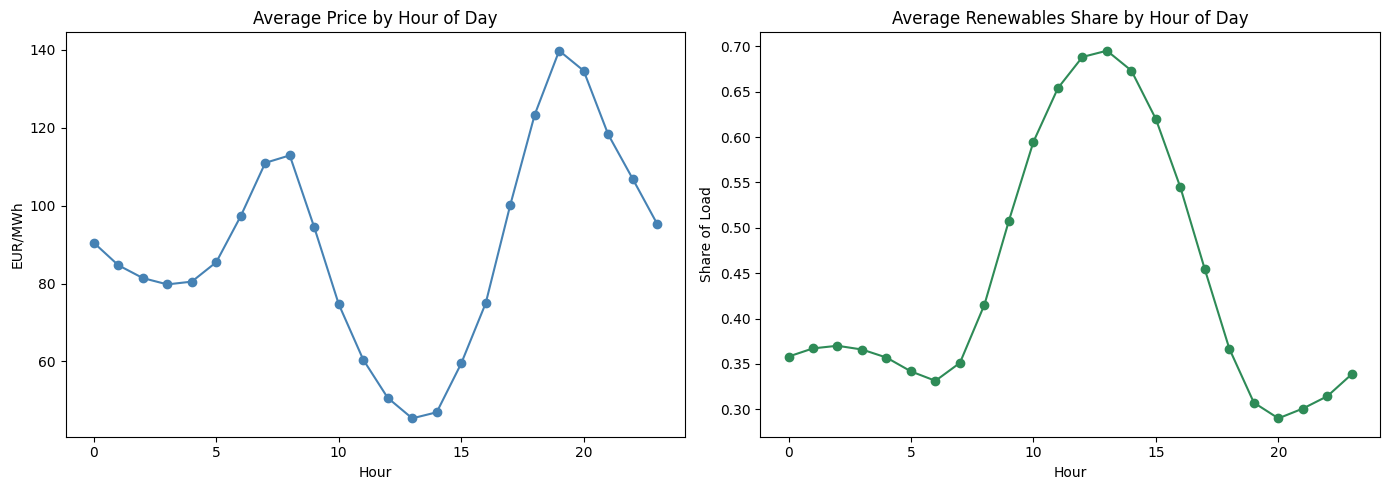

In [10]:
# --- Time features ---
df['hour'] = df.index.hour
df['month'] = df.index.month
df['season'] = pd.cut(df['month'], bins=[0,3,6,9,12], 
                      labels=['Winter','Spring','Summer','Autumn'])

# --- Average price by hour ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('hour')['price_EUR_MWh'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Average Price by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('EUR/MWh')

# --- Average renewables share by hour ---
df.groupby('hour')['renewables_share'].mean().plot(ax=axes[1], marker='o', color='seagreen')
axes[1].set_title('Average Renewables Share by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Share of Load')

plt.tight_layout()
plt.show()

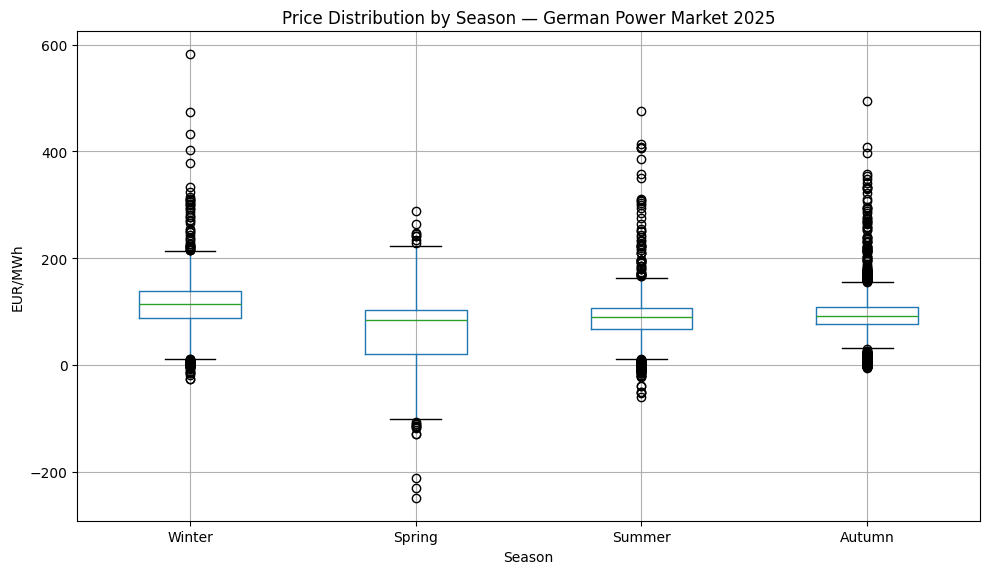

In [11]:
# --- Price distribution by season ---
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='price_EUR_MWh', by='season', ax=ax)
ax.set_title('Price Distribution by Season — German Power Market 2025')
ax.set_xlabel('Season')
ax.set_ylabel('EUR/MWh')
plt.suptitle('')
plt.tight_layout()
plt.show()


## Key Finding 1: Renewables Share is the Dominant Price Driver

Correlation between renewables_share and price_EUR_MWh: -0.80

This confirms the merit order effect — as zero-marginal-cost wind and solar 
generation increases as a share of total load, expensive thermal plants are 
pushed off the margin, collapsing the clearing price. 

Solar (-0.55) is a stronger individual driver than wind onshore (-0.30), 
reflecting its concentrated midday generation profile and price cannibalization effect.

## Key Finding 2: Intraday Price Structure Mirrors Renewables Profile

Prices follow a predictable intraday pattern:
- Morning peak ~08:00 (demand rises before solar generation)
- Midday trough ~13:00 (solar generation peaks, renewables share ~70%)
- Evening peak ~19:00-20:00 (solar gone, demand still high, renewables share ~30%)

The evening peak is 3x the midday trough on average.

## Key Finding 3: Seasonal Volatility Profile

Winter: Highest median prices, extreme upside spikes. Low solar, thermal dependency.
Spring: Most negative price events. Solar strong, heating demand collapsed — oversupply.
Summer/Autumn: Tighter distributions, more forecastable.

Implication: Price risk is asymmetric by season. Winter risk is upside spike. 
Spring risk is negative price cannibalisation for generators.
